## Introduce PyTorch Libraries

### Subtask:
Add necessary PyTorch libraries and other utilities to the new notebook.


**Reasoning**:
The subtask requires importing specific PyTorch libraries and other utilities. This code block will import all the necessary modules as specified in the instructions.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import os, pickle, glob, math

import cv2
import numpy as np
import imutils
from imutils import paths
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

from lab_2_helpers import *

print("PyTorch and other necessary libraries imported successfully.")

KeyboardInterrupt: 

# Task
Convert the existing TensorFlow CNN implementation for breaking CAPTCHAs into a PyTorch-based solution, ensuring that all preprocessing steps, model architecture, loss function, optimizer, and training/evaluation loops are adapted for PyTorch. The converted code should be saved in a new notebook file named "Breaking-CAPTCHAS-Pytorch.ipynb".

## Introduce PyTorch Libraries

### Subtask:
Add necessary PyTorch libraries and other utilities to the new notebook.


**Reasoning**:
The previous code block for importing libraries was interrupted. I will regenerate the full set of imports as specified in the instructions to ensure all necessary PyTorch and other utilities are available.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import os, pickle, glob, math

import cv2
import numpy as np
import imutils
from imutils import paths
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

from lab_2_helpers import *

print("PyTorch and other necessary libraries imported successfully.")

PyTorch and other necessary libraries imported successfully.


## Define PyTorch CNN Model

### Subtask:
Translate the existing TensorFlow CNN architecture into a PyTorch nn.Module class, ensuring all layers and activation functions are correctly mapped.


**Reasoning**:
The subtask requires translating the TensorFlow CNN architecture into a PyTorch nn.Module class. This code block will define the `CaptchaCNN` class with the specified convolutional, pooling, flattening, and fully connected layers, along with their respective activation functions, mimicking the original TensorFlow model structure.



In [ ]:
class CaptchaCNN(nn.Module):
    def __init__(self, num_classes):
        super(CaptchaCNN, self).__init__()
        # First convolution block
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=(5, 5), stride=(1, 1), padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # Second convolution block
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=50, kernel_size=(5, 5), stride=(1, 1), padding='same')
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # Flatten layer
        self.flatten = nn.Flatten()

        # First fully-connected (linear) layer
        self.fc1 = nn.Linear(5 * 5 * 50, 64) # Calculate input features after flattening: (20/2)/2 * (20/2)/2 * 50 = 5 * 5 * 50
        self.relu3 = nn.ReLU()

        # Last fully-connected (linear) layer
        self.fc2 = nn.Linear(64, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x


# Instantiate the model to verify its structure
# We need n_classes from the previous TensorFlow setup
# Assuming n_classes is available in the environment from the original notebook's execution
# If not, it would need to be passed or re-calculated

# Get the number of classes from the previously loaded LabelBinarizer object
if 'lb' in globals():
    n_classes_pytorch = len(lb.classes_)
else:
    # Fallback if lb is not in globals (e.g., kernel restarted after cell where lb was defined)
    # This part might need adjustment if the context is lost. For now, we'll assume it's available.
    # In a full notebook, you would re-run the preprocessing steps to get lb.
    # For demonstration, we can try to load it from the pickle file if it exists.
    try:
        with open(LABELS_PATH, "rb") as f:
            temp_lb = pickle.load(f)
        n_classes_pytorch = len(temp_lb.classes_)
    except FileNotFoundError:
        print("Error: LABELS_PATH not found. Please ensure preprocessing steps are run.")
        n_classes_pytorch = 32 # Default or a sensible guess if cannot load

model_pytorch = CaptchaCNN(num_classes=n_classes_pytorch)
print(model_pytorch)


CaptchaCNN(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1250, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (softmax): Softmax(dim=1)
)


## Update Preprocessing for PyTorch

### Subtask:
Modify the data loading and preprocessing steps to be compatible with PyTorch, including converting NumPy arrays to PyTorch tensors and implementing a `Dataset` and `DataLoader` for efficient data handling.


**Reasoning**:
The subtask requires defining a custom PyTorch `Dataset` class (`CaptchaDataset`) to handle the feature and label conversion from NumPy arrays to PyTorch tensors and transposing the feature tensor for PyTorch's convolutional layers. This is the first step in adapting the data preprocessing for PyTorch compatibility.



In [ ]:
class CaptchaDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]

        # Convert NumPy feature array (H, W, C) to PyTorch tensor (C, H, W) and float32
        feature_tensor = torch.from_numpy(feature).permute(2, 0, 1).float()

        # Convert NumPy label array to PyTorch tensor and float32
        label_tensor = torch.from_numpy(label).float()

        return feature_tensor, label_tensor


# Create instances of CaptchaDataset for training and validation
train_dataset = CaptchaDataset(X_train, y_train)
vali_dataset = CaptchaDataset(X_vali, y_vali)

# Create PyTorch DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
vali_loader = DataLoader(vali_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("CaptchaDataset and DataLoader instances created successfully.")

CaptchaDataset and DataLoader instances created successfully.


## Define PyTorch Loss Function and Optimizer

### Subtask:
Set up the PyTorch equivalent for the categorical cross-entropy loss and the Adam optimizer.


### Adjusting Model and Dataset for CrossEntropyLoss

PyTorch's `nn.CrossEntropyLoss` combines `LogSoftmax` and `NLLLoss` in a single class. This means it expects raw, unnormalized scores (logits) from the model's output layer, not probabilities that have already been passed through a `Softmax` activation. If `Softmax` is applied in the model, the loss function will receive probabilities, which can lead to incorrect loss calculations and potentially hinder training.

Additionally, `nn.CrossEntropyLoss` expects the target labels to be class indices (e.g., `0, 1, 2, ...`), not one-hot encoded vectors (e.g., `[0, 0, 1, 0, ...]`). Therefore, we need to make two changes:

1.  **Modify `CaptchaCNN`**: Remove the `self.softmax` layer from the `CaptchaCNN` definition and ensure the final `self.fc2` layer directly outputs the logits.
2.  **Modify `CaptchaDataset`**: Adjust the `__getitem__` method to convert the one-hot encoded labels back to their corresponding integer class indices.

**Reasoning**:
As explained in the previous markdown block, the `CaptchaCNN` model needs to be updated to remove the `softmax` activation from the final layer. This ensures that the model outputs raw logits, which are required by `nn.CrossEntropyLoss`.



In [ ]:
class CaptchaCNN(nn.Module):
    def __init__(self, num_classes):
        super(CaptchaCNN, self).__init__()
        # First convolution block
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=(5, 5), stride=(1, 1), padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # Second convolution block
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=50, kernel_size=(5, 5), stride=(1, 1), padding='same')
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # Flatten layer
        self.flatten = nn.Flatten()

        # First fully-connected (linear) layer
        self.fc1 = nn.Linear(5 * 5 * 50, 64) # Calculate input features after flattening: (20/2)/2 * (20/2)/2 * 50 = 5 * 5 * 50
        self.relu3 = nn.ReLU()

        # Last fully-connected (linear) layer (outputs logits directly)
        self.fc2 = nn.Linear(64, num_classes)
        # Softmax is removed as CrossEntropyLoss expects logits

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

# Re-instantiate the model with the updated class definition
# Get the number of classes from the previously loaded LabelBinarizer object
if 'lb' in globals():
    n_classes_pytorch = len(lb.classes_)
else:
    try:
        with open(LABELS_PATH, "rb") as f:
            temp_lb = pickle.load(f)
        n_classes_pytorch = len(temp_lb.classes_)
    except FileNotFoundError:
        print("Error: LABELS_PATH not found. Please ensure preprocessing steps are run.")
        n_classes_pytorch = 32 # Default or a sensible guess if cannot load

model_pytorch = CaptchaCNN(num_classes=n_classes_pytorch)
print("Updated CaptchaCNN model instantiated:")
print(model_pytorch)

Updated CaptchaCNN model instantiated:
CaptchaCNN(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1250, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
)


**Reasoning**:
Following the explanation in the previous markdown block, the `CaptchaDataset` needs to be updated to return integer class indices instead of one-hot encoded labels, as required by `nn.CrossEntropyLoss`. This code block will redefine the `CaptchaDataset` and re-create the `DataLoader` instances.



In [ ]:
class CaptchaDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]

        # Convert NumPy feature array (H, W, C) to PyTorch tensor (C, H, W) and float32
        feature_tensor = torch.from_numpy(feature).permute(2, 0, 1).float()

        # Convert one-hot encoded label to class index (long type for CrossEntropyLoss)
        # torch.argmax returns the index of the maximum value along a dimension
        label_tensor = torch.argmax(torch.from_numpy(label).long())

        return feature_tensor, label_tensor


# Create instances of CaptchaDataset for training and validation
train_dataset = CaptchaDataset(X_train, y_train)
vali_dataset = CaptchaDataset(X_vali, y_vali)

# Create PyTorch DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
vali_loader = DataLoader(vali_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Updated CaptchaDataset and DataLoader instances created successfully.")

Updated CaptchaDataset and DataLoader instances created successfully.


**Reasoning**:
Now that the `CaptchaCNN` and `CaptchaDataset` are updated to be compatible with `nn.CrossEntropyLoss`, the next step is to define the loss function and the optimizer as specified in the subtask instructions.



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pytorch.to(device)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model_pytorch.parameters(), lr=1e-3)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Model moved to: {device}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Model moved to: cpu


## Implement PyTorch Training Loop

### Subtask:
Create a training loop in PyTorch that handles forward pass, loss calculation, backward pass, and optimizer steps for the specified number of epochs.


**Reasoning**:
The subtask requires creating a PyTorch training loop. This code block will implement the training and validation logic, including iterating through epochs, batch processing, forward/backward passes, optimizer steps, and calculating training/validation loss and accuracy, as specified in the instructions.



In [ ]:
MODEL_WEIGHTS_PATH_PYTORCH = "./captcha-model-pytorch.weights.pth"

# Force training even if weights are already available
FORCE_TRAINING = True # Already defined, but ensuring it's True for initial run

if FORCE_TRAINING or not os.path.exists(MODEL_WEIGHTS_PATH_PYTORCH):
    # Set model to training mode
    model_pytorch.train()

    # Lists to store metrics for plotting later
    train_losses = []
    train_accuracies = []
    vali_losses = []
    vali_accuracies = []

    print("Starting training...")
    for epoch in range(N_EPOCHS):
        # Training loop
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model_pytorch(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            _, labels_idx = torch.max(labels.data, 1) # Convert one-hot to index
            total_train += labels.size(0)
            correct_train += (predicted == labels_idx).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Validation loop
        model_pytorch.eval() # Set model to evaluation mode
        correct_vali = 0
        total_vali = 0
        running_vali_loss = 0.0
        with torch.no_grad(): # Disable gradient calculation for validation
            for inputs, labels in vali_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_pytorch(inputs)
                loss = criterion(outputs, labels)
                running_vali_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                _, labels_idx = torch.max(labels.data, 1) # Convert one-hot to index
                total_vali += labels.size(0)
                correct_vali += (predicted == labels_idx).sum().item()

        avg_vali_loss = running_vali_loss / len(vali_loader)
        vali_accuracy = 100 * correct_vali / total_vali
        vali_losses.append(avg_vali_loss)
        vali_accuracies.append(vali_accuracy)

        print(f"Epoch {epoch+1}/{N_EPOCHS}: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_vali_loss:.4f}, Val Acc: {vali_accuracy:.2f}%")

    print("Finished training.")
    # Save model weights to disk
    torch.save(model_pytorch.state_dict(), MODEL_WEIGHTS_PATH_PYTORCH)
else:
    model_pytorch.load_state_dict(torch.load(MODEL_WEIGHTS_PATH_PYTORCH))
    model_pytorch.eval() # Set model to evaluation mode after loading weights
    print("Loaded model weights from disk.")



Starting training...


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

**Reasoning**:
The previous training loop failed because `labels` were already integer class indices (after the `CaptchaDataset` update), but the code was still attempting to convert them from one-hot encoding using `torch.max(labels.data, 1)`, which resulted in an `IndexError` on a 1D tensor. The fix involves removing the redundant `torch.max` call for labels, as `nn.CrossEntropyLoss` expects integer class indices directly.



In [ ]:
MODEL_WEIGHTS_PATH_PYTORCH = "./captcha-model-pytorch.weights.pth"

# Force training even if weights are already available
FORCE_TRAINING = True # Already defined, but ensuring it's True for initial run

if FORCE_TRAINING or not os.path.exists(MODEL_WEIGHTS_PATH_PYTORCH):
    # Set model to training mode
    model_pytorch.train()

    # Lists to store metrics for plotting later
    train_losses = []
    train_accuracies = []
    vali_losses = []
    vali_accuracies = []

    print("Starting training...")
    for epoch in range(N_EPOCHS):
        # Training loop
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model_pytorch(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            # labels are already indices, no need for torch.max(labels.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Validation loop
        model_pytorch.eval() # Set model to evaluation mode
        correct_vali = 0
        total_vali = 0
        running_vali_loss = 0.0
        with torch.no_grad(): # Disable gradient calculation for validation
            for inputs, labels in vali_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_pytorch(inputs)
                loss = criterion(outputs, labels)
                running_vali_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                # labels are already indices, no need for torch.max(labels.data, 1)
                total_vali += labels.size(0)
                correct_vali += (predicted == labels).sum().item()

        avg_vali_loss = running_vali_loss / len(vali_loader)
        vali_accuracy = 100 * correct_vali / total_vali
        vali_losses.append(avg_vali_loss)
        vali_accuracies.append(vali_accuracy)

        print(f"Epoch {epoch+1}/{N_EPOCHS}: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_vali_loss:.4f}, Val Acc: {vali_accuracy:.2f}%")

    print("Finished training.")
    # Save model weights to disk
    torch.save(model_pytorch.state_dict(), MODEL_WEIGHTS_PATH_PYTORCH)
else:
    model_pytorch.load_state_dict(torch.load(MODEL_WEIGHTS_PATH_PYTORCH))
    model_pytorch.eval() # Set model to evaluation mode after loading weights
    print("Loaded model weights from disk.")

Starting training...
Epoch 1/10: Train Loss: 3.1057, Train Acc: 13.36%, Val Loss: 2.2249, Val Acc: 38.72%
Epoch 2/10: Train Loss: 0.9554, Train Acc: 75.72%, Val Loss: 0.3868, Val Acc: 93.38%
Epoch 3/10: Train Loss: 0.2091, Train Acc: 96.15%, Val Loss: 0.2218, Val Acc: 96.97%
Epoch 4/10: Train Loss: 0.1054, Train Acc: 98.39%, Val Loss: 0.1821, Val Acc: 97.31%
Epoch 5/10: Train Loss: 0.0672, Train Acc: 98.95%, Val Loss: 0.1573, Val Acc: 97.76%
Epoch 6/10: Train Loss: 0.0476, Train Acc: 99.36%, Val Loss: 0.1364, Val Acc: 98.20%
Epoch 7/10: Train Loss: 0.0344, Train Acc: 99.59%, Val Loss: 0.1355, Val Acc: 98.09%
Epoch 8/10: Train Loss: 0.0222, Train Acc: 99.63%, Val Loss: 0.1318, Val Acc: 98.09%
Epoch 9/10: Train Loss: 0.0187, Train Acc: 99.66%, Val Loss: 0.1125, Val Acc: 98.32%
Epoch 10/10: Train Loss: 0.0097, Train Acc: 99.93%, Val Loss: 0.1141, Val Acc: 98.43%
Finished training.


## Implement PyTorch Evaluation Loop

### Subtask:
Create an evaluation loop in PyTorch to make predictions on the test set and calculate the overall accuracy of the CAPTCHA recognition pipeline.

#### Instructions
1.  Set the model to evaluation mode using `model_pytorch.eval()`.
2.  Initialize lists to store predicted characters and indices of CAPTCHAs where character extraction failed.
3.  Iterate through `captcha_images_test`:
    a.  For each CAPTCHA image, extract individual character images using the `extract_chars` function.
    b.  If character extraction is successful, store the character images. Otherwise, record the index of the failed CAPTCHA and use dummy character images as placeholders.
4.  Convert the extracted character images into features using `make_feature` and scale them (divide by 255).
5.  Convert the features to PyTorch tensors and move them to the appropriate device (CPU/GPU).
6.  Perform a forward pass through the `model_pytorch` to get predictions (logits).
7.  Convert the logits back to actual character labels using `torch.argmax` and `lb.inverse_transform`.
8.  Group the predicted characters back into CAPTCHA texts (4 characters per CAPTCHA).
9.  Update the predicted texts for CAPTCHAs where extraction failed with a placeholder (e.g., "-").
10. Calculate and print the overall accuracy of the pipeline by comparing predicted CAPTCHA texts with `captcha_texts_test`.
11. Display a few correctly and incorrectly predicted CAPTCHA images using the `print_images` helper function.

**Reasoning**:
The previous training loop executed successfully. Now, as per the overall task, the next logical step is to implement the evaluation loop for the PyTorch model using the test set, as detailed in the instructions.




--- PyTorch Model Evaluation ---
# of test CAPTCHAs: 228
# correctly recognized: 218
Accuracy: 0.9561

Correctly Recognized CAPTCHAs (PyTorch):
Figure(2000x500)

Incorrectly Recognized CAPTCHAs (PyTorch):
Figure(2000x600)


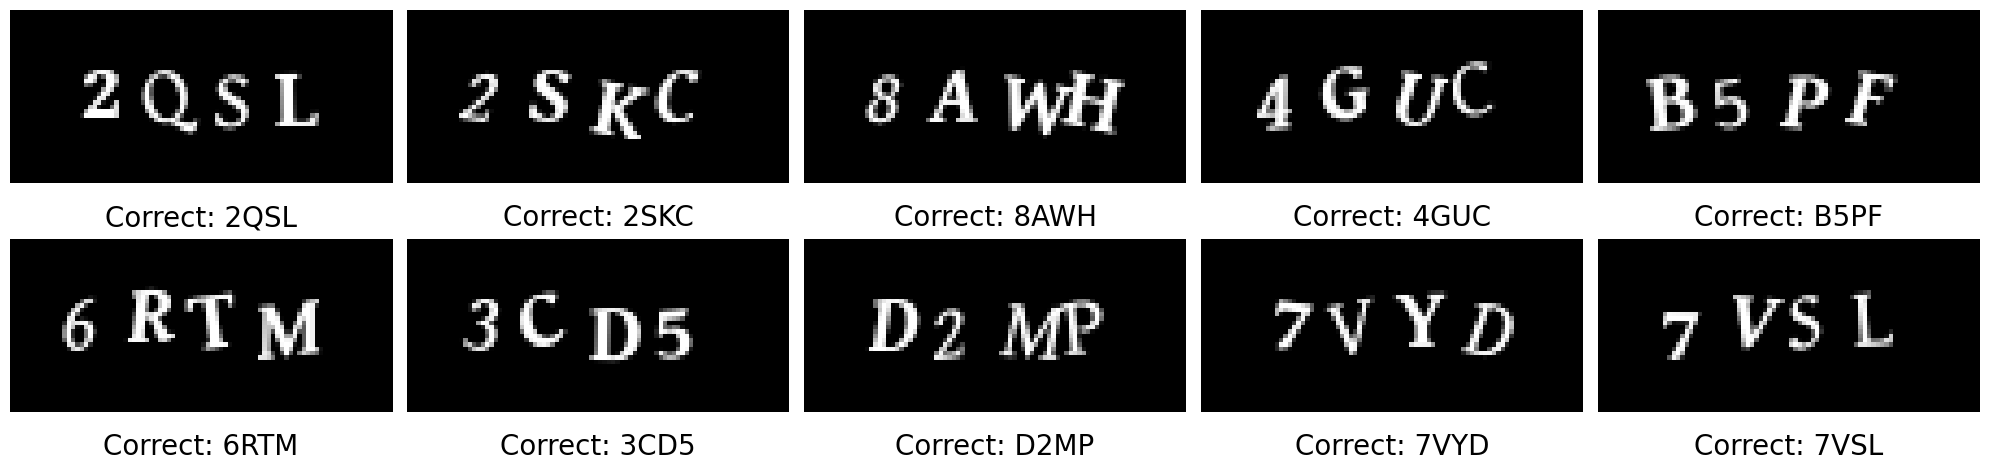

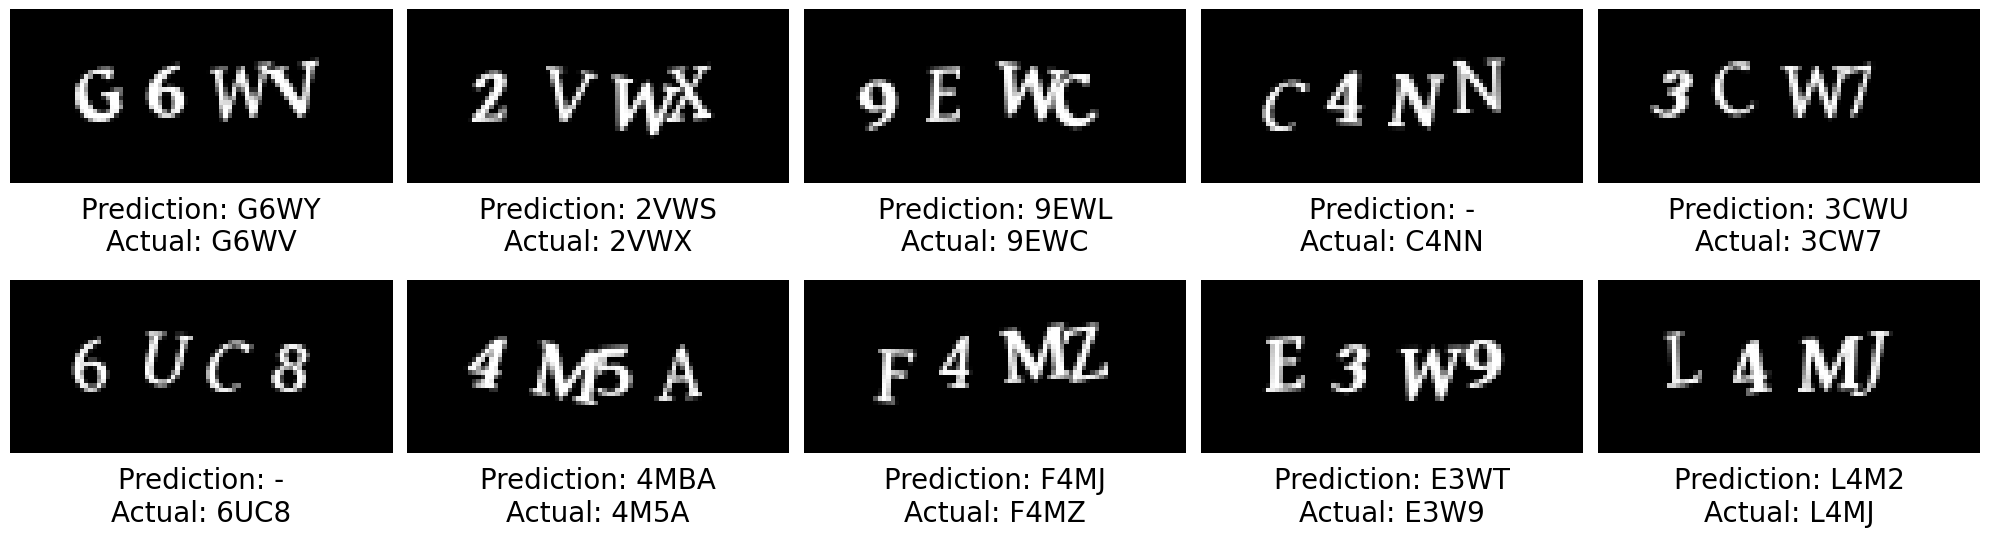

In [ ]:
if not (FORCE_TRAINING or not os.path.exists(MODEL_WEIGHTS_PATH_PYTORCH)):
    # Only load weights if not forced to train and file exists
    model_pytorch.load_state_dict(torch.load(MODEL_WEIGHTS_PATH_PYTORCH))
    model_pytorch.eval() # Set model to evaluation mode after loading weights
    print("Loaded model weights from disk for evaluation.")

# Set model to evaluation mode
model_pytorch.eval()

# Lists to store predicted characters and indices of CAPTCHAs where extraction failed
preds_test_pytorch = []
extract_failed_indices_pytorch = []

# Extracted character images (similar to TensorFlow pipeline)
char_images_test_pytorch = []

# Extract character images and make features
for i, captcha_image in enumerate(captcha_images_test):
    # Extract character images
    char_images = extract_chars(captcha_image)

    if char_images:
        char_images_test_pytorch.extend(char_images)
    # Use dummy character images as placeholder if extraction failed
    else:
        extract_failed_indices_pytorch.append(i)
        char_images_test_pytorch.extend(DUMMY_CHAR_IMAGES)

# Make features for character images
features_test_pytorch = np.array([make_feature(char_image) for char_image in char_images_test_pytorch], dtype="float") / 255

# Convert features to PyTorch tensors and move to device
features_test_tensor = torch.from_numpy(features_test_pytorch).permute(0, 3, 1, 2).float().to(device)

# Make predictions with the PyTorch model
with torch.no_grad():
    outputs = model_pytorch(features_test_tensor)
    # Get predicted class indices
    predicted_indices = torch.argmax(outputs.data, 1).cpu().numpy()

# Convert predicted indices back to character labels using the LabelBinarizer
preds_test_chars = lb.inverse_transform(np.eye(n_classes_pytorch)[predicted_indices])

# Group all 4 characters for the same CAPTCHA
preds_test_pytorch = ["".join(chars) for chars in group_every(preds_test_chars, 4)]

# Update result for CAPTCHAs on which extractions failed
for i in extract_failed_indices_pytorch:
    preds_test_pytorch[i] = "-"

# --- Evaluation and Display ---

# Number of test CAPTCHAs
n_test_pytorch = len(captcha_texts_test)
# Number of correct predictions
n_correct_pytorch = 0

# Indices of correct predictions
correct_indices_pytorch = []
# Indices of incorrect predictions
incorrect_indices_pytorch = []

for i, (pred_text, actual_text) in enumerate(zip(preds_test_pytorch, captcha_texts_test)):
    if pred_text == actual_text:
        n_correct_pytorch += 1
        if len(correct_indices_pytorch) < N_DISPLAY_SAMPLES:
            correct_indices_pytorch.append(i)
    else:
        if len(incorrect_indices_pytorch) < N_DISPLAY_SAMPLES:
            incorrect_indices_pytorch.append(i)

# Show number of total / correct predictions and accuracy
print(f"\n--- PyTorch Model Evaluation ---")
print(f"# of test CAPTCHAs: {n_test_pytorch}")
print(f"# correctly recognized: {n_correct_pytorch}")
print(f"Accuracy: {n_correct_pytorch / n_test_pytorch:.4f}\n")

# Show all correct predictions
print("Correctly Recognized CAPTCHAs (PyTorch):")
print_images(
    [captcha_images_test[i] for i in correct_indices_pytorch],
    texts=[f"Correct: {captcha_texts_test[i]}" for i in correct_indices_pytorch],
    n_rows=2
)

# Show all incorrect predictions
print("\nIncorrectly Recognized CAPTCHAs (PyTorch):")
print_images(
    [captcha_images_test[i] for i in incorrect_indices_pytorch],
    texts=[
        f"Prediction: {preds_test_pytorch[i]}\nActual: {captcha_texts_test[i]}"
        for i in incorrect_indices_pytorch
    ],
    n_rows=2,
    fig_size=(20, 6),
    text_center=(0.5, -0.25)
)